# Supplementary Figure S5

Two cohort volcanoes and two sensitivity forests.

Run from top to bottom. All scientific and plotting code is contained in this notebook.

## Data lineage

Packaged source table(s): `data/figs5ab.csv`, `data/figs5cd.csv`. They were deterministically extracted by `scripts/reviewer_data/extract_figure_data.py` from retained author analysis tables and manuscript-frozen contracts. The cells below expose every reviewer-side filter, sort, grouping, pivot, coordinate calculation, and plot export. Checksums, schemas, row counts, privacy class, and extraction metadata are recorded in `data/manifest.json`.


In [1]:
from pathlib import Path
from typing import Any
import hashlib
import json
import math
import os

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from matplotlib.lines import Line2D
from matplotlib.path import Path as MplPath
from matplotlib.patches import FancyBboxPatch, PathPatch
from IPython.display import Image, Markdown, display

# Locate For_Reviewer when Jupyter starts in the repository root,
# For_Reviewer, or For_Reviewer/notebooks.
_candidates = []
for _base in (Path.cwd(), *Path.cwd().parents):
    _candidates.extend((_base, _base / "For_Reviewer"))
ROOT = next(
    (
        _path.resolve()
        for _path in _candidates
        if (_path / "notebooks" / "Data_Preparation.ipynb").is_file() and (_path / "README.md").is_file()
    ),
    None,
)
if ROOT is None:
    raise RuntimeError("Could not locate the For_Reviewer folder.")

DATA = Path(os.environ.get("LINKD_REPRO_DATA_DIR", ROOT / "data")).resolve()
STATIC = Path(os.environ.get("LINKD_REPRO_STATIC_DIR", ROOT / "static")).resolve()
MANIFEST = DATA / "manifest.json"
RECOVERY_COMMAND = "Open notebooks/Data_Preparation.ipynb and choose Restart Kernel and Run All."
if not MANIFEST.is_file():
    raise FileNotFoundError(f"Missing {MANIFEST}. {RECOVERY_COMMAND}")

_manifest_entries = json.loads(MANIFEST.read_text(encoding="utf-8"))
_manifest_by_path = {entry["path"]: entry for entry in _manifest_entries}

def verify_input(path):
    """Verify a packaged panel table immediately before loading it."""
    relative = path.relative_to(DATA).as_posix()
    entry = _manifest_by_path.get(relative)
    if entry is None or not path.is_file():
        raise FileNotFoundError(f"Missing packaged input: {path}. {RECOVERY_COMMAND}")
    digest = hashlib.sha256(path.read_bytes()).hexdigest()
    if digest != entry["sha256"]:
        raise RuntimeError(f"Checksum mismatch for {path}. {RECOVERY_COMMAND}")

PANELS = DATA
ILLUSTRATIONS = STATIC
OUTPUT_ROOT = Path(os.environ.get("LINKD_REPRO_OUTPUT_DIR", ROOT / "outputs")).resolve()
OUTPUT_FIG = OUTPUT_ROOT / "figures"
OUTPUT_DATA = OUTPUT_ROOT / "source_data"
OUTPUT_FIG.mkdir(parents=True, exist_ok=True)
OUTPUT_DATA.mkdir(parents=True, exist_ok=True)

mpl.rcParams.update({
    "font.family": "sans-serif", "font.sans-serif": ["Helvetica", "Arial", "DejaVu Sans"],
    "font.size": 8, "axes.labelsize": 8, "axes.titlesize": 9,
    "xtick.labelsize": 7, "ytick.labelsize": 7, "legend.fontsize": 7,
    "axes.linewidth": 0.6, "xtick.major.width": 0.6, "ytick.major.width": 0.6,
    "pdf.fonttype": 42, "ps.fonttype": 42, "figure.dpi": 150, "savefig.dpi": 300,
    "axes.spines.top": False, "axes.spines.right": False,
})
BLUE = "#4C78A8"; RED = "#E45756"; TEAL = "#2A9D8F"; ORANGE = "#F4A261"; GREY = "#B8B8B8"

def panel_label(ax, value):
    ax.text(-0.15, 1.05, value, transform=ax.transAxes, fontsize=11,
            fontweight="bold", va="top")

def show_static(panel_id, title):
    """Display a submitted static panel and its bundled provenance note."""
    folder = ILLUSTRATIONS / panel_id
    process = folder / "PROCESS.md"
    if not process.is_file():
        raise FileNotFoundError(f"Missing provenance: {process}. {RECOVERY_COMMAND}")
    display(Markdown(f"### {title}\n\n" + process.read_text(encoding="utf-8")))
    assets = sorted([
        *folder.glob("*.png"), *folder.glob("*.jpg"),
        *folder.glob("*.jpeg"), *folder.glob("*.pdf"),
    ])
    if not assets:
        raise FileNotFoundError(f"Missing submitted asset in {folder}. {RECOVERY_COMMAND}")
    raster = next(
        (path for path in assets if path.suffix.lower() in {".png", ".jpg", ".jpeg"}),
        None,
    )
    if raster is not None:
        display(Image(filename=str(raster), width=720))
    else:
        display(Markdown(f"Submitted PDF asset: `{assets[0]}`"))

print("Reviewer package:", ROOT)
print("Panel data:", DATA)
print("Static assets:", STATIC)
print("Outputs:", OUTPUT_ROOT)



Reviewer package: /Users/cheng.wang/Documents/LinkD_Agent/For_Reviewer
Panel data: /Users/cheng.wang/Documents/LinkD_Agent/For_Reviewer/data
Static assets: /Users/cheng.wang/Documents/LinkD_Agent/For_Reviewer/static
Outputs: /Users/cheng.wang/Documents/LinkD_Agent/For_Reviewer/outputs


## figS5 a — Mount Sinai volcano

This section contains the complete data loading, validation, transformation, plotting, and export code for this submitted panel.

In [2]:
verify_input(PANELS / "figs5ab.csv")
data = pd.read_csv(PANELS / "figs5ab.csv")
print("shape:", data.shape)
print("columns:", data.columns.tolist())
display(data.head())

shape: (664, 7)
columns: ['Drug Name', 'ICD10', 'cohort', 'odds_ratio', 'p_bonf', 'neglog10_p', 'status']


,Drug Name,ICD10,cohort,odds_ratio,p_bonf,neglog10_p,status
0,Dextrose,C61,Mount Sinai EHR,0.845495,0.030900,1.510045,Beneficial
1,Pantoprazole,C61,Mount Sinai EHR,0.888109,1.000000,-0.000000,NS
2,Magnesium Hydroxide,C61,Mount Sinai EHR,0.837336,0.030304,1.518504,Beneficial
3,Perflutren,C61,Mount Sinai EHR,0.777420,0.000008,5.083938,Beneficial
4,Hydralazine,C61,Mount Sinai EHR,0.812576,0.002437,2.613138,Beneficial


In [3]:
assert "Mount Sinai EHR" in set(data["cohort"])
assert data["p_bonf"].between(0, 1).all()
print("PASS — figS5_a manuscript invariants")

PASS — figS5_a manuscript invariants


In [4]:
prepared = data.loc[data["cohort"] == "Mount Sinai EHR"].copy()
print("prepared shape:", prepared.shape)
display(prepared.head())

prepared shape: (513, 7)


,Drug Name,ICD10,cohort,odds_ratio,p_bonf,neglog10_p,status
0,Dextrose,C61,Mount Sinai EHR,0.845495,0.030900,1.510045,Beneficial
1,Pantoprazole,C61,Mount Sinai EHR,0.888109,1.000000,-0.000000,NS
2,Magnesium Hydroxide,C61,Mount Sinai EHR,0.837336,0.030304,1.518504,Beneficial
3,Perflutren,C61,Mount Sinai EHR,0.777420,0.000008,5.083938,Beneficial
4,Hydralazine,C61,Mount Sinai EHR,0.812576,0.002437,2.613138,Beneficial


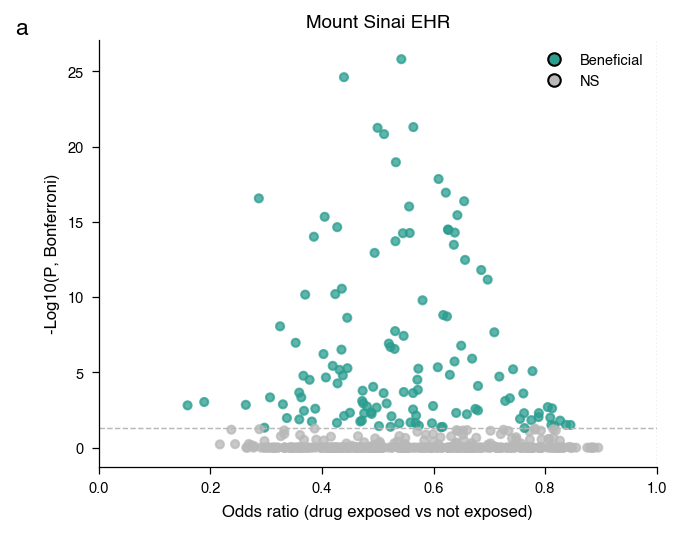

In [5]:
def plot_volcano(data: pd.DataFrame) -> tuple[plt.Figure, pd.DataFrame]:
    cohort = str(data["cohort"].iloc[0])
    fig, ax = plt.subplots(figsize=(4.8, 3.7))
    colors = data["status"].map({"Beneficial": TEAL, "NS": GREY})
    ax.scatter(data["odds_ratio"], data["neglog10_p"], c=colors, s=15, alpha=.75)
    ax.axvline(1, color=GREY, ls=":", lw=.7); ax.axhline(-math.log10(.05), color=GREY, ls="--", lw=.7)
    ax.set(xlim=(0, 1), xlabel="Odds ratio (drug exposed vs not exposed)",
           ylabel="-Log10(P, Bonferroni)", title=cohort)
    ax.legend(handles=[Line2D([], [], marker="o", color="none", markerfacecolor=TEAL, label="Beneficial"),
                       Line2D([], [], marker="o", color="none", markerfacecolor=GREY, label="NS")],
              frameon=False)
    panel_label(ax, "a" if cohort == "Mount Sinai EHR" else "b"); return fig, data


figure, plotted_source = plot_volcano(prepared)
display(figure)
plt.close(figure)

In [6]:
pdf_path = OUTPUT_FIG / "figS5_a_mount_sinai.pdf"
png_path = OUTPUT_FIG / "figS5_a_mount_sinai.png"
csv_path = OUTPUT_DATA / "figS5_a_mount_sinai.csv"
figure.savefig(pdf_path, bbox_inches="tight", metadata={"Title": "figS5_a_mount_sinai", "Author": "LinkD figure reproduction package", "Creator": "matplotlib"})
figure.savefig(png_path, bbox_inches="tight", dpi=300)
plotted_source.to_csv(csv_path, index=False, lineterminator="\n")
assert pdf_path.stat().st_size > 0 and png_path.stat().st_size > 0 and csv_path.stat().st_size > 0
print("PDF:", pdf_path)
print("PNG:", png_path)
print("CSV:", csv_path)
print("Panel result: Bonferroni-corrected associations are reproduced.")

1 extra bytes in post.stringData array


'created' timestamp seems very low; regarding as unix timestamp


PDF: /Users/cheng.wang/Documents/LinkD_Agent/For_Reviewer/outputs/figures/figS5_a_mount_sinai.pdf
PNG: /Users/cheng.wang/Documents/LinkD_Agent/For_Reviewer/outputs/figures/figS5_a_mount_sinai.png
CSV: /Users/cheng.wang/Documents/LinkD_Agent/For_Reviewer/outputs/source_data/figS5_a_mount_sinai.csv
Panel result: Bonferroni-corrected associations are reproduced.


## figS5 b — UK Biobank volcano

This section contains the complete data loading, validation, transformation, plotting, and export code for this submitted panel.

In [7]:
verify_input(PANELS / "figs5ab.csv")
data = pd.read_csv(PANELS / "figs5ab.csv")
print("shape:", data.shape)
print("columns:", data.columns.tolist())
display(data.head())

shape: (664, 7)
columns: ['Drug Name', 'ICD10', 'cohort', 'odds_ratio', 'p_bonf', 'neglog10_p', 'status']


,Drug Name,ICD10,cohort,odds_ratio,p_bonf,neglog10_p,status
0,Dextrose,C61,Mount Sinai EHR,0.845495,0.030900,1.510045,Beneficial
1,Pantoprazole,C61,Mount Sinai EHR,0.888109,1.000000,-0.000000,NS
2,Magnesium Hydroxide,C61,Mount Sinai EHR,0.837336,0.030304,1.518504,Beneficial
3,Perflutren,C61,Mount Sinai EHR,0.777420,0.000008,5.083938,Beneficial
4,Hydralazine,C61,Mount Sinai EHR,0.812576,0.002437,2.613138,Beneficial


In [8]:
assert "UK Biobank" in set(data["cohort"])
assert data["p_bonf"].between(0, 1).all()
print("PASS — figS5_b manuscript invariants")

PASS — figS5_b manuscript invariants


In [9]:
prepared = data.loc[data["cohort"] == "UK Biobank"].copy()
print("prepared shape:", prepared.shape)
display(prepared.head())

prepared shape: (151, 7)


,Drug Name,ICD10,cohort,odds_ratio,p_bonf,neglog10_p,status
513,Quetiapine,C44,UK Biobank,0.136,3.773927e-15,14.423206,Beneficial
514,Quetiapine,C61,UK Biobank,0.216,5.466529e-06,5.262288,Beneficial
515,Ezetimibe,C61,UK Biobank,0.412,4.886503e-161,160.311002,Beneficial
516,Ezetimibe,C20,UK Biobank,0.297,3.552037e-50,49.449522,Beneficial
517,Ezetimibe,C22,UK Biobank,0.317,2.095124e-15,14.678790,Beneficial


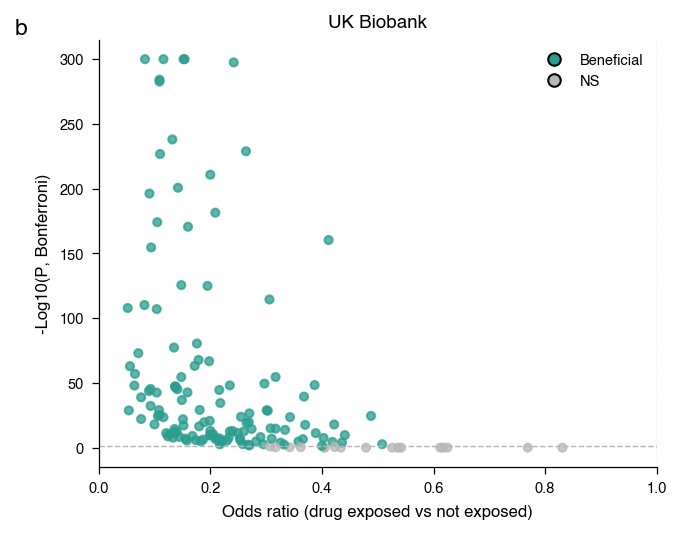

In [10]:
def plot_volcano(data: pd.DataFrame) -> tuple[plt.Figure, pd.DataFrame]:
    cohort = str(data["cohort"].iloc[0])
    fig, ax = plt.subplots(figsize=(4.8, 3.7))
    colors = data["status"].map({"Beneficial": TEAL, "NS": GREY})
    ax.scatter(data["odds_ratio"], data["neglog10_p"], c=colors, s=15, alpha=.75)
    ax.axvline(1, color=GREY, ls=":", lw=.7); ax.axhline(-math.log10(.05), color=GREY, ls="--", lw=.7)
    ax.set(xlim=(0, 1), xlabel="Odds ratio (drug exposed vs not exposed)",
           ylabel="-Log10(P, Bonferroni)", title=cohort)
    ax.legend(handles=[Line2D([], [], marker="o", color="none", markerfacecolor=TEAL, label="Beneficial"),
                       Line2D([], [], marker="o", color="none", markerfacecolor=GREY, label="NS")],
              frameon=False)
    panel_label(ax, "a" if cohort == "Mount Sinai EHR" else "b"); return fig, data


figure, plotted_source = plot_volcano(prepared)
display(figure)
plt.close(figure)

In [11]:
pdf_path = OUTPUT_FIG / "figS5_b_ukb.pdf"
png_path = OUTPUT_FIG / "figS5_b_ukb.png"
csv_path = OUTPUT_DATA / "figS5_b_ukb.csv"
figure.savefig(pdf_path, bbox_inches="tight", metadata={"Title": "figS5_b_ukb", "Author": "LinkD figure reproduction package", "Creator": "matplotlib"})
figure.savefig(png_path, bbox_inches="tight", dpi=300)
plotted_source.to_csv(csv_path, index=False, lineterminator="\n")
assert pdf_path.stat().st_size > 0 and png_path.stat().st_size > 0 and csv_path.stat().st_size > 0
print("PDF:", pdf_path)
print("PNG:", png_path)
print("CSV:", csv_path)
print("Panel result: Bonferroni-corrected associations are reproduced.")

1 extra bytes in post.stringData array


'created' timestamp seems very low; regarding as unix timestamp


PDF: /Users/cheng.wang/Documents/LinkD_Agent/For_Reviewer/outputs/figures/figS5_b_ukb.pdf
PNG: /Users/cheng.wang/Documents/LinkD_Agent/For_Reviewer/outputs/figures/figS5_b_ukb.png
CSV: /Users/cheng.wang/Documents/LinkD_Agent/For_Reviewer/outputs/source_data/figS5_b_ukb.csv
Panel result: Bonferroni-corrected associations are reproduced.


## figS5 c — Azelastine sensitivity analysis

This section contains the complete data loading, validation, transformation, plotting, and export code for this submitted panel.

In [12]:
verify_input(PANELS / "figs5cd.csv")
data = pd.read_csv(PANELS / "figs5cd.csv")
print("shape:", data.shape)
print("columns:", data.columns.tolist())
display(data.head())

shape: (22, 6)
columns: ['association', 'test', 'odds_ratio', 'lower', 'upper', 'p_value']


,association,test,odds_ratio,lower,upper,p_value
0,Azelastine and liver cancer,Test 1,0.64,0.461426,0.887684,0.0075
1,Azelastine and liver cancer,Test 2,0.58,0.423284,0.794738,0.0007
2,Azelastine and liver cancer,Test 3,0.75,0.541810,1.038187,0.0829
3,Azelastine and liver cancer,Test 4,0.73,0.525346,1.014379,0.0608
4,Azelastine and liver cancer,Test 5,0.69,0.498693,0.954696,0.0251


In [13]:
summary = data[(data["association"] == "Azelastine and liver cancer") & (data["test"] == "Summary")].iloc[0]
assert np.isclose(summary["odds_ratio"], 0.69)
print("PASS — figS5_c manuscript invariants")

PASS — figS5_c manuscript invariants


In [14]:
prepared = data.loc[data["association"] == "Azelastine and liver cancer"].copy()
print("prepared shape:", prepared.shape)
display(prepared.head())

prepared shape: (11, 6)


,association,test,odds_ratio,lower,upper,p_value
0,Azelastine and liver cancer,Test 1,0.64,0.461426,0.887684,0.0075
1,Azelastine and liver cancer,Test 2,0.58,0.423284,0.794738,0.0007
2,Azelastine and liver cancer,Test 3,0.75,0.541810,1.038187,0.0829
3,Azelastine and liver cancer,Test 4,0.73,0.525346,1.014379,0.0608
4,Azelastine and liver cancer,Test 5,0.69,0.498693,0.954696,0.0251


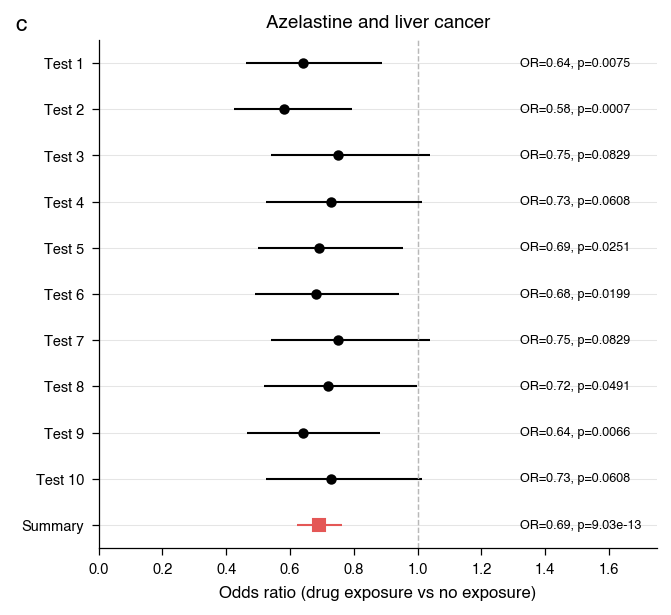

In [15]:
def plot_sensitivity(data: pd.DataFrame) -> tuple[plt.Figure, pd.DataFrame]:
    association = str(data["association"].iloc[0]); letter = "c" if association.startswith("Azelastine") else "d"
    fig, ax = plt.subplots(figsize=(4.8, 4.4)); y = np.arange(len(data))[::-1]
    for idx, (_, row) in enumerate(data.iterrows()):
        color = RED if row["test"] == "Summary" else "black"
        ax.errorbar(row["odds_ratio"], y[idx],
                    xerr=[[row["odds_ratio"]-row["lower"]], [row["upper"]-row["odds_ratio"]]],
                    fmt="s" if row["test"] == "Summary" else "o", color=color, ecolor=color,
                    capsize=0, markersize=6 if row["test"] == "Summary" else 4, lw=1)
        p = f"{row['p_value']:.2e}" if row["test"] == "Summary" else f"{row['p_value']:.4f}"
        ax.text(1.32, y[idx], f"OR={row['odds_ratio']:.2f}, p={p}", va="center", fontsize=6)
    ax.axvline(1, color=GREY, ls="--", lw=.7); ax.set_xlim(0, 1.75)
    ax.set_yticks(y, data["test"]); ax.set_xlabel("Odds ratio (drug exposure vs no exposure)")
    ax.set_title(association); ax.grid(axis="y", color="#E5E5E5", lw=.5)
    panel_label(ax, letter); return fig, data


figure, plotted_source = plot_sensitivity(prepared)
display(figure)
plt.close(figure)

In [16]:
pdf_path = OUTPUT_FIG / "figS5_c_azelastine.pdf"
png_path = OUTPUT_FIG / "figS5_c_azelastine.png"
csv_path = OUTPUT_DATA / "figS5_c_azelastine.csv"
figure.savefig(pdf_path, bbox_inches="tight", metadata={"Title": "figS5_c_azelastine", "Author": "LinkD figure reproduction package", "Creator": "matplotlib"})
figure.savefig(png_path, bbox_inches="tight", dpi=300)
plotted_source.to_csv(csv_path, index=False, lineterminator="\n")
assert pdf_path.stat().st_size > 0 and png_path.stat().st_size > 0 and csv_path.stat().st_size > 0
print("PDF:", pdf_path)
print("PNG:", png_path)
print("CSV:", csv_path)
print("Panel result: Submitted summary OR 0.69 is reproduced.")

1 extra bytes in post.stringData array


'created' timestamp seems very low; regarding as unix timestamp


PDF: /Users/cheng.wang/Documents/LinkD_Agent/For_Reviewer/outputs/figures/figS5_c_azelastine.pdf
PNG: /Users/cheng.wang/Documents/LinkD_Agent/For_Reviewer/outputs/figures/figS5_c_azelastine.png
CSV: /Users/cheng.wang/Documents/LinkD_Agent/For_Reviewer/outputs/source_data/figS5_c_azelastine.csv
Panel result: Submitted summary OR 0.69 is reproduced.


## figS5 d — Tretinoin sensitivity analysis

This section contains the complete data loading, validation, transformation, plotting, and export code for this submitted panel.

In [17]:
verify_input(PANELS / "figs5cd.csv")
data = pd.read_csv(PANELS / "figs5cd.csv")
print("shape:", data.shape)
print("columns:", data.columns.tolist())
display(data.head())

shape: (22, 6)
columns: ['association', 'test', 'odds_ratio', 'lower', 'upper', 'p_value']


,association,test,odds_ratio,lower,upper,p_value
0,Azelastine and liver cancer,Test 1,0.64,0.461426,0.887684,0.0075
1,Azelastine and liver cancer,Test 2,0.58,0.423284,0.794738,0.0007
2,Azelastine and liver cancer,Test 3,0.75,0.541810,1.038187,0.0829
3,Azelastine and liver cancer,Test 4,0.73,0.525346,1.014379,0.0608
4,Azelastine and liver cancer,Test 5,0.69,0.498693,0.954696,0.0251


In [18]:
summary = data[(data["association"] == "Tretinoin and thyroid cancer") & (data["test"] == "Summary")].iloc[0]
assert np.isclose(summary["odds_ratio"], 0.43)
print("PASS — figS5_d manuscript invariants")

PASS — figS5_d manuscript invariants


In [19]:
prepared = data.loc[data["association"] == "Tretinoin and thyroid cancer"].copy()
print("prepared shape:", prepared.shape)
display(prepared.head())

prepared shape: (11, 6)


,association,test,odds_ratio,lower,upper,p_value
11,Tretinoin and thyroid cancer,Test 1,0.43,0.209991,0.880514,0.0210
12,Tretinoin and thyroid cancer,Test 2,0.42,0.205336,0.859079,0.0175
13,Tretinoin and thyroid cancer,Test 3,0.50,0.240912,1.037723,0.0628
14,Tretinoin and thyroid cancer,Test 4,0.33,0.163917,0.664362,0.0019
15,Tretinoin and thyroid cancer,Test 5,0.60,0.284926,1.263485,0.1788


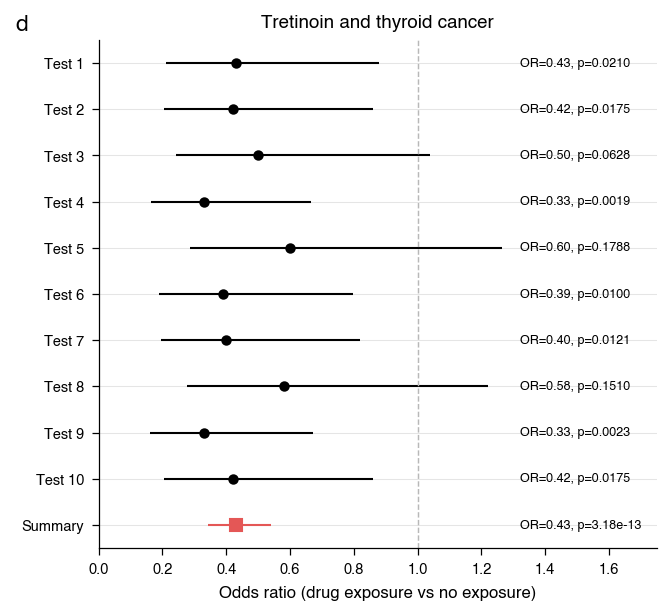

In [20]:
def plot_sensitivity(data: pd.DataFrame) -> tuple[plt.Figure, pd.DataFrame]:
    association = str(data["association"].iloc[0]); letter = "c" if association.startswith("Azelastine") else "d"
    fig, ax = plt.subplots(figsize=(4.8, 4.4)); y = np.arange(len(data))[::-1]
    for idx, (_, row) in enumerate(data.iterrows()):
        color = RED if row["test"] == "Summary" else "black"
        ax.errorbar(row["odds_ratio"], y[idx],
                    xerr=[[row["odds_ratio"]-row["lower"]], [row["upper"]-row["odds_ratio"]]],
                    fmt="s" if row["test"] == "Summary" else "o", color=color, ecolor=color,
                    capsize=0, markersize=6 if row["test"] == "Summary" else 4, lw=1)
        p = f"{row['p_value']:.2e}" if row["test"] == "Summary" else f"{row['p_value']:.4f}"
        ax.text(1.32, y[idx], f"OR={row['odds_ratio']:.2f}, p={p}", va="center", fontsize=6)
    ax.axvline(1, color=GREY, ls="--", lw=.7); ax.set_xlim(0, 1.75)
    ax.set_yticks(y, data["test"]); ax.set_xlabel("Odds ratio (drug exposure vs no exposure)")
    ax.set_title(association); ax.grid(axis="y", color="#E5E5E5", lw=.5)
    panel_label(ax, letter); return fig, data


figure, plotted_source = plot_sensitivity(prepared)
display(figure)
plt.close(figure)

In [21]:
pdf_path = OUTPUT_FIG / "figS5_d_tretinoin.pdf"
png_path = OUTPUT_FIG / "figS5_d_tretinoin.png"
csv_path = OUTPUT_DATA / "figS5_d_tretinoin.csv"
figure.savefig(pdf_path, bbox_inches="tight", metadata={"Title": "figS5_d_tretinoin", "Author": "LinkD figure reproduction package", "Creator": "matplotlib"})
figure.savefig(png_path, bbox_inches="tight", dpi=300)
plotted_source.to_csv(csv_path, index=False, lineterminator="\n")
assert pdf_path.stat().st_size > 0 and png_path.stat().st_size > 0 and csv_path.stat().st_size > 0
print("PDF:", pdf_path)
print("PNG:", png_path)
print("CSV:", csv_path)
print("Panel result: Submitted summary OR 0.43 is reproduced.")

1 extra bytes in post.stringData array


'created' timestamp seems very low; regarding as unix timestamp


PDF: /Users/cheng.wang/Documents/LinkD_Agent/For_Reviewer/outputs/figures/figS5_d_tretinoin.pdf
PNG: /Users/cheng.wang/Documents/LinkD_Agent/For_Reviewer/outputs/figures/figS5_d_tretinoin.png
CSV: /Users/cheng.wang/Documents/LinkD_Agent/For_Reviewer/outputs/source_data/figS5_d_tretinoin.csv
Panel result: Submitted summary OR 0.43 is reproduced.


## Complete

All assigned panels were displayed inline and exported as PDF, PNG, and source CSV where computational.